In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import scanpy as sc
import seaborn as sns

import os
import pyBigWig

In [212]:
#colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
#unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]

cat_colors_list = ['#263238', '#2E5BFF', "#D4AF37",  '#D81B60','#E65100',  '#7B1FA2',  '#558B2F',]  # ,   '#94A3B8'
unique_categories =['common', 'SADE unique', 'CR unique', 'TSS unique', 'CR+TSS, not SADE', 'SADE+TSS, not CR', 'SADE+CR, not TSS']
cat_colors_map = dict(zip(unique_categories, cat_colors_list))    

In [3]:
hg38_genes_file='/home/syyang/CR/refdata-cellranger-arc-GRCh38-2020-A-2.0.0/genes/genes.gtf.gz'
hg38_genes_df = pd.read_csv(hg38_genes_file, sep='\t', comment='#', header=None,
                            names=['chrom', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'],
                            compression='gzip')
hg38_genes_genes_df = hg38_genes_df[hg38_genes_df['feature'] == 'gene'].copy()


hg38_genes_genes_df['gene_name'] = hg38_genes_genes_df['attribute'].apply(lambda x: [item for item in x.split(';') if 'gene_name' in item][0].split(' ')[-1].replace('"', ''))
hg38_genes_genes_df.head(2)

,chrom,source,feature,start,end,score,strand,frame,attribute,gene_name
0,chr1,HAVANA,gene,29554,31109,.,+,.,"gene_id ""ENSG00000243485""; gene_version ""5""; g...",MIR1302-2HG
8,chr1,HAVANA,gene,34554,36081,.,-,.,"gene_id ""ENSG00000237613""; gene_version ""2""; g...",FAM138A


In [4]:
# blacklist region 
blacklist_region_file = '/home/syyang/GitRepo/atac/ref/hg38/hg38-blacklist.bed'
blacklist_region_df = pd.read_csv(blacklist_region_file, sep='\t', header=None, names=['chrom', 'start', 'end', 'name'])
blacklist_region_df.head(2)

,chrom,start,end,name
0,chr10,0,45700,Low Mappability
1,chr10,38481300,38596500,High Signal Region


# Load Data

## Load entropy results

In [5]:
# Load Entropy value for each barcode on atac (if any barcode has invalid entropy value, it's not included in the file)
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_df_file = os.path.join(entropy_dir, 'calculated_barcode_entropy_wDNAdebrisflag_df.tsv')
entropy_df = pd.read_csv(entropy_df_file, sep=',', index_col=0)
entropy_df['log10_Entropy'] = np.log10(entropy_df['Entropy'])
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,log10_Entropy
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,-2.285327
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,-0.690589


In [6]:
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_stringent_calling.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info['invalid_entropy'] = union_cell_info['Entropy'].isna()
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac,P_closed_state,stringent_cell_calling,invalid_entropy
atac_bc,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common,0.965116,True,False
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common,0.990949,True,False


In [7]:
union_cell_info['Entropy'].isna().sum()

np.int64(22)

## Given some barcodes could have invalid entropy and does not have a record -- load fragment file 

In [8]:
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_BC'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])
frag['frag_length'] = frag['end'] - frag['start']



In [9]:
union_cell_info.groupby(['invalid_entropy', '_2set_identified_by_atac_SC']).size().unstack(fill_value=0)

_2set_identified_by_atac_SC,both,cr_only,entropy_only,none
invalid_entropy,,,,
False,1865,81,236,180
True,0,13,0,9


In [10]:
union_cell_info.groupby(['DNA_debris', '_2set_identified_by_atac_SC']).size().unstack(fill_value=0)

_2set_identified_by_atac_SC,both,cr_only,entropy_only,none
DNA_debris,,,,
NO,1865,72,236,189
YES,0,22,0,0


In [11]:
total_frag_per_bc = frag.groupby('atac_bc').size()

<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1982947/2214799348.py:41: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('ATAC read depth ($\log_{1p}$)', fontsize=12, labelpad=10)


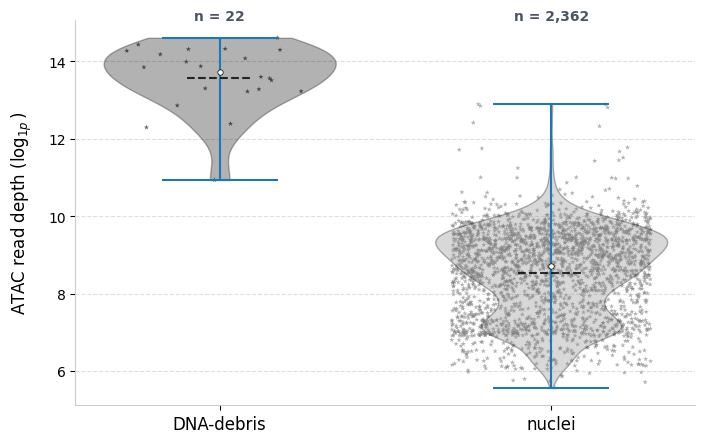

In [12]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, alpha=0.5, color='orange', marker='*', edgecolors='none', lw=1):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=alpha, s=15, zorder=1, marker=marker, lw=lw, edgecolors=edgecolors) # s controls point size


fig, ax = plt.subplots(figsize=(8, 5))
total_frag = [union_cell_info['total_fragments'][union_cell_info['DNA_debris'] == 'YES'], 
              union_cell_info['total_fragments'][union_cell_info['DNA_debris'] == 'NO']]
total_frag = [np.log1p(f) for f in total_frag]
x_positions = np.arange(len(total_frag))
v1 = ax.violinplot(total_frag, positions=x_positions, widths=0.7)
colors_list = [ 'black', 'grey']  # red for DNA debris, blue for clean

np.random.seed(999) # For reproducibility of jitter

for i, group_data in enumerate(total_frag):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_list[i], alpha=0.6)


total_counts = [ frip.shape[0] for frip in total_frag ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] , f'n = {count:,}', ha='center', 
            fontsize=10, color='#4B5563', fontweight='bold')

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_list[i])
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(total_frag):
    quartile1, median, quartile3 = np.percentile(group_data, [25, 50, 75])
    mean = np.mean(group_data)
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle='--', lw=1.5, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=0.5)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels(['DNA-debris', 'nuclei'], fontsize=12, fontweight='medium', rotation=0, ha='center')
ax.set_ylabel('ATAC read depth ($\log_{1p}$)', fontsize=12, labelpad=10)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# legend_elements = [
#     Line2D([0], [0], marker='o', color='w', label='Median', markerfacecolor='white', markeredgecolor='black', markersize=6),
#     Line2D([0], [0], marker='_', color='black', label='Mean', markersize=6, markeredgewidth=1.5, linestyle='--'),
# ]
# ax.legend(handles=legend_elements, loc='lower left', frameon=False, fontsize=10, bbox_to_anchor=(1, 0.85))

# fig.tight_layout()

2
3
4
-----------------------------------------
------  invalid entropy 	 DNA debris 	 ATAC pass entropy 	 ATAC pass CR 	 ATAC pass archr TSS
Mean:   	2.95 	 	 5.9 	 	 3.8 	 	 3.9 		  3.8
Median: 	2.87 	 	 6.0 	 	 3.9 	 	 3.9 		  3.8


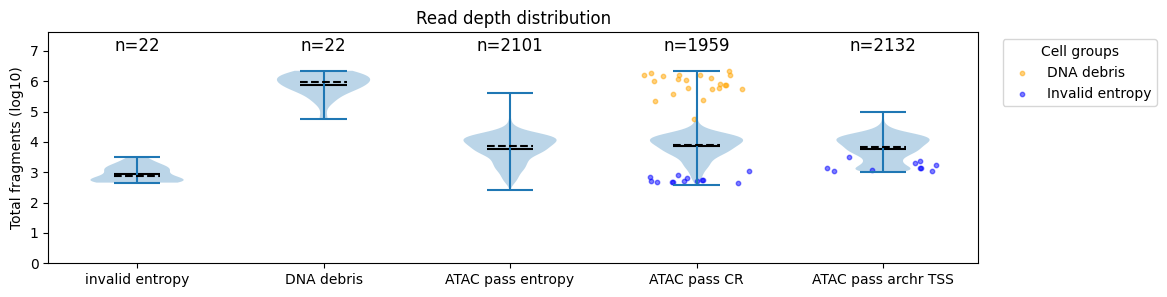

In [13]:
# Add dots to the violin plot with jitter
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):

    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    return ax.scatter(x_jittered, data_group, color=color, alpha=0.5, s=10) # s controls point size



fig, ax = plt.subplots(figsize=(12,3))
np.random.seed(999) # for reproducibility of jittered points


read_depth_list = [total_frag_per_bc.loc[union_cell_info[union_cell_info['invalid_entropy'] == True].index],
                   total_frag_per_bc.loc[union_cell_info[union_cell_info['DNA_debris'] == 'YES'].index],
                   total_frag_per_bc.loc[union_cell_info[union_cell_info['atac_pass_entropy'] == True].index],
                   total_frag_per_bc.loc[union_cell_info[union_cell_info['atac_pass_CR'] == True].index], 
                     total_frag_per_bc.loc[union_cell_info[union_cell_info['atac_pass_archr_TSS'] == True].index]]
read_depth_list = [np.log10(a + 1) for a in read_depth_list]
total_counts = [len(a) for a in read_depth_list]
x_pos = np.arange(len(read_depth_list))

v1 = ax.violinplot(read_depth_list, positions=x_pos, showmeans=True, showmedians=True)


v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_pos)
ax.set_xticklabels(['invalid entropy', 'DNA debris', 'ATAC pass entropy', 'ATAC pass CR', 'ATAC pass archr TSS'], rotation=0, ha='center')
ax.set_ylabel('Total fragments (log10)')
ax.set_title('Read depth distribution')
ax.set_ylim(0, np.log10(total_frag_per_bc.max()+ 1) * 1.2)

for i, count in enumerate(total_counts):
    ax.text(x_pos[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)


DNA_debris_cells = union_cell_info[union_cell_info['DNA_debris'] == 'YES'].copy()
DNA_debris_readdepth_values = [total_frag_per_bc.loc[DNA_debris_cells[DNA_debris_cells['atac_pass_entropy'] == True].index],
                                total_frag_per_bc.loc[DNA_debris_cells[DNA_debris_cells['atac_pass_CR'] == True].index],  
                                  total_frag_per_bc.loc[DNA_debris_cells[DNA_debris_cells['atac_pass_archr_TSS'] == True].index]]
DNA_debris_readdepth_values = [np.log10(a + 1) for a in DNA_debris_readdepth_values]
for group_data, i in zip(DNA_debris_readdepth_values, [2, 3, 4]):
    print(i)
    s1 = add_jittered_points(ax, group_data, i, color='orange')

Invalid_entropy_cells = union_cell_info[union_cell_info['invalid_entropy'] == True].copy()
Invalid_entropy_readdepth_values = [ total_frag_per_bc.loc[Invalid_entropy_cells[Invalid_entropy_cells['atac_pass_entropy'] == True].index], 
                                  total_frag_per_bc.loc[Invalid_entropy_cells[Invalid_entropy_cells['atac_pass_CR'] == True].index],
                                  total_frag_per_bc.loc[Invalid_entropy_cells[Invalid_entropy_cells['atac_pass_archr_TSS'] == True].index]]
Invalid_entropy_readdepth_values = [np.log10(a + 1) for a in Invalid_entropy_readdepth_values]
for group_data, i in zip(Invalid_entropy_readdepth_values, [2, 3, 4]):
    s2 = add_jittered_points(ax, group_data, i, color='blue')

ax.legend([s1, s2], ['DNA debris', 'Invalid entropy'], loc='upper right', bbox_to_anchor=(1.2, 1), title='Cell groups')


mean_read_depth = [a.mean() for a in read_depth_list]
median_read_depth = [a.median() for a in read_depth_list]
print(f"-----------------------------------------")
print(f"------  invalid entropy \t DNA debris \t ATAC pass entropy \t ATAC pass CR \t ATAC pass archr TSS")
print(f"Mean:   \t{mean_read_depth[0]:.2f} \t \t {mean_read_depth[1]:.1f} \t \t {mean_read_depth[2]:.1f} \t \t {mean_read_depth[3]:.1f} \t\t  {mean_read_depth[4]:.1f}")
print(f"Median: \t{median_read_depth[0]:.2f} \t \t {median_read_depth[1]:.1f} \t \t {median_read_depth[2]:.1f} \t \t {median_read_depth[3]:.1f} \t\t  {median_read_depth[4]:.1f}")

-----------------------------------------
------  invalid entropy 	 Valid entropy
Mean:   1072.14 	  18614.6
Median: 740.50 	  6327.0


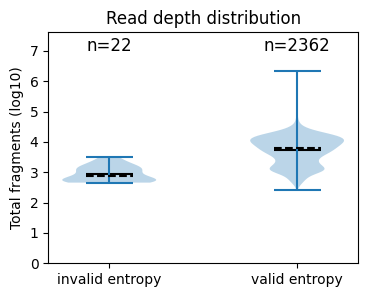

In [14]:
fig, ax = plt.subplots(figsize=(4,3))


read_depth_list = [total_frag_per_bc.loc[union_cell_info[union_cell_info['invalid_entropy'] == True].index],
                   total_frag_per_bc.loc[union_cell_info[union_cell_info['invalid_entropy'] == False].index]]
total_counts = [len(a) for a in read_depth_list]
x_pos = [0, 1]

v1 = ax.violinplot([np.log10(a + 1) for a in read_depth_list], positions=x_pos, showmeans=True, showmedians=True)


v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_pos)
ax.set_xticklabels(['invalid entropy', 'valid entropy'])
ax.set_ylabel('Total fragments (log10)')
ax.set_title('Read depth distribution')
ax.set_ylim(0, np.log10(total_frag_per_bc.max()+ 1) * 1.2)

for i, count in enumerate(total_counts):
    ax.text(x_pos[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)


mean_read_depth = [a.mean() for a in read_depth_list]
median_read_depth = [a.median() for a in read_depth_list]
print(f"-----------------------------------------")
print(f"------  invalid entropy \t Valid entropy")
print(f"Mean:   {mean_read_depth[0]:.2f} \t  {mean_read_depth[1]:.1f}")
print(f"Median: {median_read_depth[0]:.2f} \t  {median_read_depth[1]:.1f}")

# Check P_closed_states

In [15]:
entropy_df['atac_bc'] = entropy_df.index.str.split('-1').str[0]
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,log10_Entropy,atac_bc
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,-2.285327,CAGGTTACAGCCTAAA
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,-0.690589,GAACAATGTCGGTTAT


In [16]:
union_cell_info['P_closed_state'] = union_cell_info.index.map(entropy_df.set_index('atac_bc')['P_closed_state'])

In [17]:
union_cell_info.loc[union_cell_info['_2set_identified_by_atac_ST'] == 'entropy_only', 'P_closed_state'].head(2)

atac_bc
AAACCGCCAGAAACCC    0.985494
AACCCGGCAGTGCCTC    0.985139
Name: P_closed_state, dtype: float64

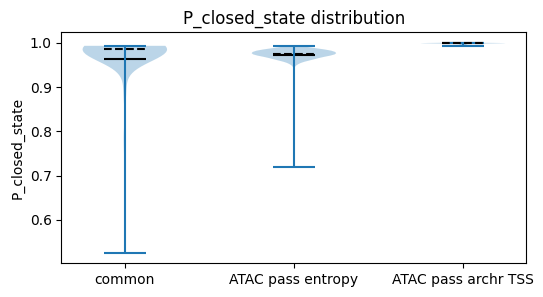

In [18]:
fig, ax = plt.subplots(figsize=(6,3))

p_closed_state_list = [union_cell_info.loc[union_cell_info['_2set_identified_by_atac_ST'] == 'entropy_only', 'P_closed_state'], 
                          union_cell_info.loc[union_cell_info['_2set_identified_by_atac_ST'] == 'both', 'P_closed_state'],
                          union_cell_info.loc[union_cell_info['_2set_identified_by_atac_ST'] == 'tss_only', 'P_closed_state'].fillna(1) 
]

x_pos = np.arange(len(p_closed_state_list))
v1 = ax.violinplot(p_closed_state_list, positions=x_pos, showmeans=True, showmedians=True)
ax.set_xticks(x_pos)
ax.set_xticklabels([ 'common', 'ATAC pass entropy',  'ATAC pass archr TSS'], rotation=0, ha='center')
ax.set_ylabel('P_closed_state')
ax.set_title('P_closed_state distribution')
v1['cmedians'].set_color('black')
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black')


In [19]:
union_cell_info.loc[union_cell_info['_2set_identified_by_atac_ST'] == 'tss_only', 'P_closed_state'].describe()

count    212.000000
mean       0.998299
std        0.001603
min        0.993399
25%        0.998110
50%        0.998905
75%        0.999290
max        0.999854
Name: P_closed_state, dtype: float64

In [20]:
union_cell_info.loc[union_cell_info['_2set_identified_by_atac_ST'] == 'both', 'P_closed_state'].describe()

count    1910.000000
mean        0.973115
std         0.015153
min         0.719761
25%         0.967858
50%         0.975048
75%         0.981421
max         0.993143
Name: P_closed_state, dtype: float64

In [21]:
bc_list = ['CCACAAACAACCTCGC', 'GCAAATATCCCTCGTC', 'TTCGCGCCATAGACTG']
union_cell_info.loc[union_cell_info.index.isin(bc_list)]

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac,P_closed_state,stringent_cell_calling,invalid_entropy
atac_bc,,,,,,,,,,,,,,,
CCACAAACAACCTCGC,1054,False,False,True,none,tss_only,GGTACCGGTCAGGCAT,False,0.008509,4,NO,TSS unique,0.999287,False,False
GCAAATATCCCTCGTC,1043,False,False,True,none,tss_only,AGGATGCAGCATGTCG,False,0.009764,4,NO,TSS unique,0.999166,False,False
TTCGCGCCATAGACTG,1049,False,False,True,none,tss_only,GCTCATTGTGTTTGAG,False,0.007786,4,NO,TSS unique,0.999355,False,False


# Visualize fragment length distribution

In [22]:
bc_DNAdebris_list = union_cell_info.loc[union_cell_info['DNA_debris'] == 'YES'].index.tolist()
bc_invalid_entropy_list = union_cell_info.loc[union_cell_info['invalid_entropy']].index.tolist()

bc_entropy_only_list = union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == 'SADE unique'].index.tolist()
bc_cr_only_list = union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == 'CR unique'].index.tolist()
bc_tss_only_list = union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == 'TSS unique'].index.tolist()
bc_common_list = union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == 'common'].index.tolist()
bc_SADEnCR_list = union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == 'SADE+CR, not TSS'].index.tolist()
bc_SADEnTSS_list = union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == 'SADE+TSS, not CR'].index.tolist()
bc_CRnTSS_list = union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == 'CR+TSS, not SADE'].index.tolist()

In [23]:
union_cell_info['_3set_identified_by_atac'].value_counts()

_3set_identified_by_atac
common              1792
TSS unique           189
SADE+TSS, not CR     118
SADE unique          118
SADE+CR, not TSS      73
CR unique             61
CR+TSS, not SADE      33
Name: count, dtype: int64

In [ ]:
# Keep 
# individual_bc_frag_subdir = os.path.join(Union_cell_subdir, 'cmp_SC', 'individual_bc_frag')
# if not os.path.exists(individual_bc_frag_subdir):
#     os.makedirs(individual_bc_frag_subdir)

# for l,n in zip([bc_DNAdebris_list, bc_invalid_entropy_list, bc_entropy_only_list, bc_cr_only_list, bc_common_list], 
#              ['DNA_debris', 'invalid_entropy', 'entropy_only', 'cr_only', 'common']):
#     bc_df = pd.DataFrame({'atac_BC': l})
#     bc_df.to_csv(os.path.join(individual_bc_frag_subdir, f'{n}_bc_list.tsv'), sep='\t', index=True)

## Invalid Entropy barcodes

In [24]:
union_cell_info.loc[bc_invalid_entropy_list].head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac,P_closed_state,stringent_cell_calling,invalid_entropy
atac_bc,,,,,,,,,,,,,,,
AAGCTAGGTTACTTCT,3245,False,False,True,none,tss_only,TTGACATCACGTGCTG,False,NaN,10,NO,TSS unique,NaN,False,True
ACATTACTCATTACAC,517,True,False,False,cr_only,none,CGGATAAAGGATTTGC,True,NaN,0,NO,CR unique,NaN,False,True


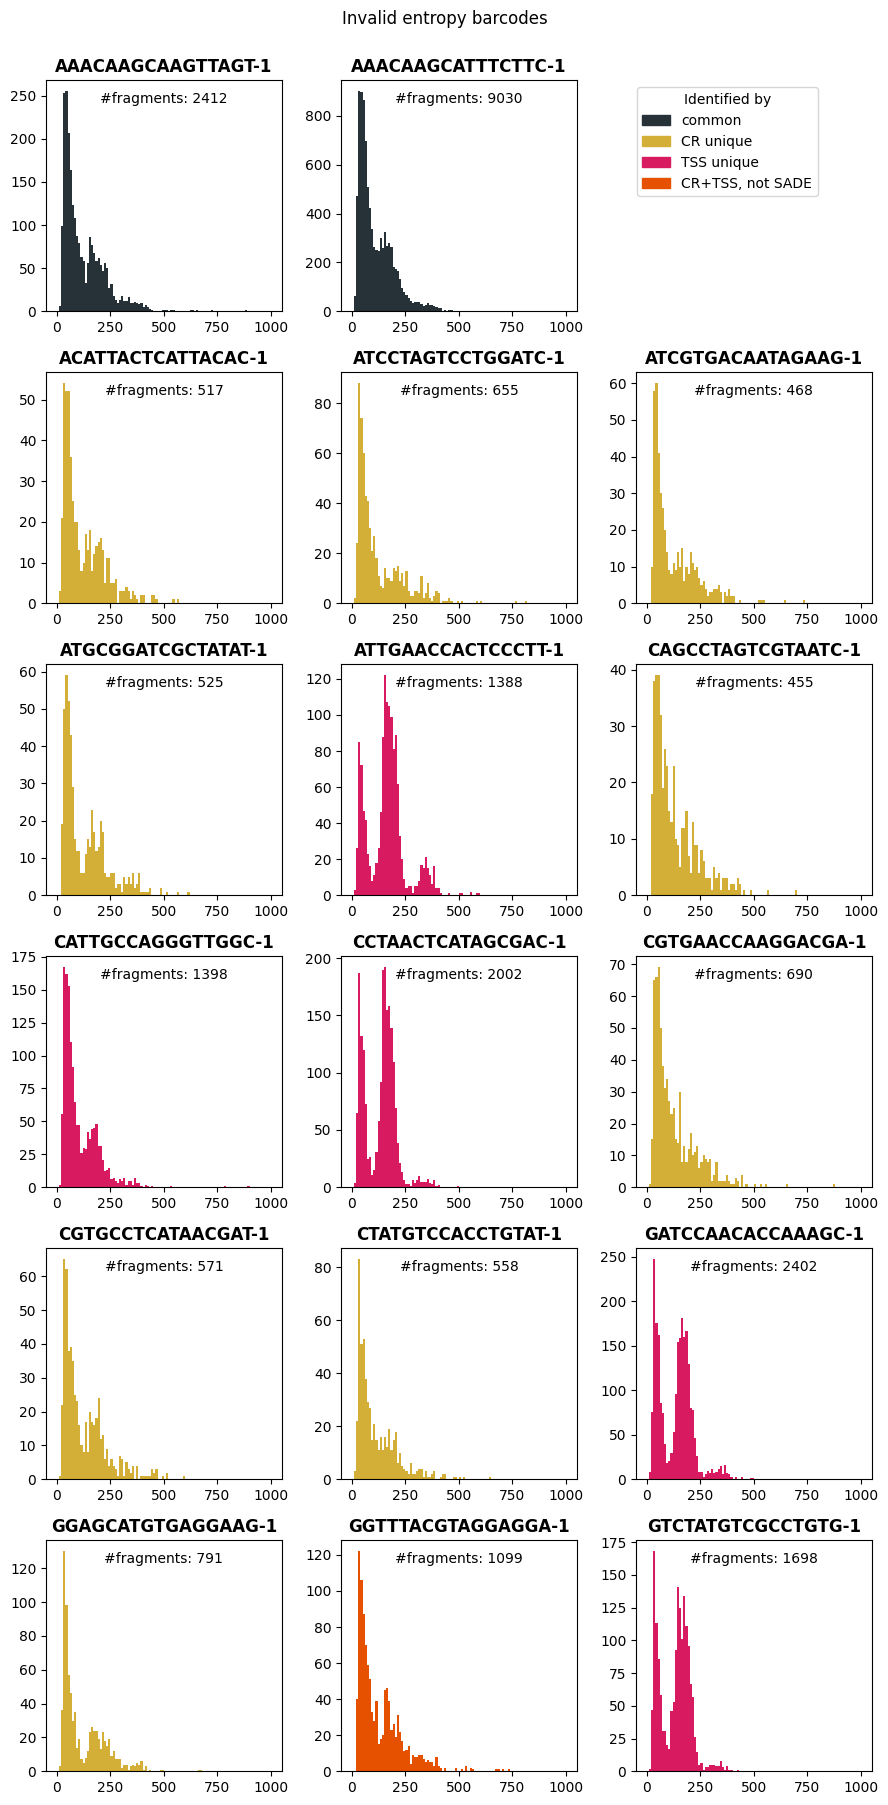

In [25]:
ncol = 3
nrow = 6
fig, ax = plt.subplots(nrow, ncol, figsize=(ncol*3, nrow*3))
ax = ax.flatten()

shown_methods = []
for i, bc in enumerate(bc_common_list[:2] + bc_invalid_entropy_list):
    if i == 2:
        ax[i].axis('off')
        continue
    if i >= nrow*ncol :
        break
    identified_method = union_cell_info.loc[bc, '_3set_identified_by_atac']
    frag_c = frag.loc[frag['atac_bc'] == bc, 'frag_length']
    _ = ax[i].hist(frag_c, bins=100, range=(0, 1000), color=cat_colors_map.get(identified_method, 'grey'))
    ax[i].text(0.5, 0.9, f'#fragments: {len(frag_c)}', transform=ax[i].transAxes, ha='center', fontsize=10, color='black')
    ax[i].set_title(bc + '-1', fontweight='bold')
    
    shown_methods.append(identified_method)

handles=[mpatches.Patch(color=cat_colors_map[method], label=method) for method in unique_categories if method in set(shown_methods)]
ax[2].legend(handles=handles, loc='upper right', bbox_to_anchor=(0.8, 1), title='Identified by')

fig.suptitle('Invalid entropy barcodes', y=1)
fig.tight_layout()

### A closer look at genome track of those barcodes

In [27]:
per_bc_subdir = os.path.join(Union_cell_subdir,'per_bc_frag_bam2')

Text(0.5, 0.08, 'Chromosome Position')

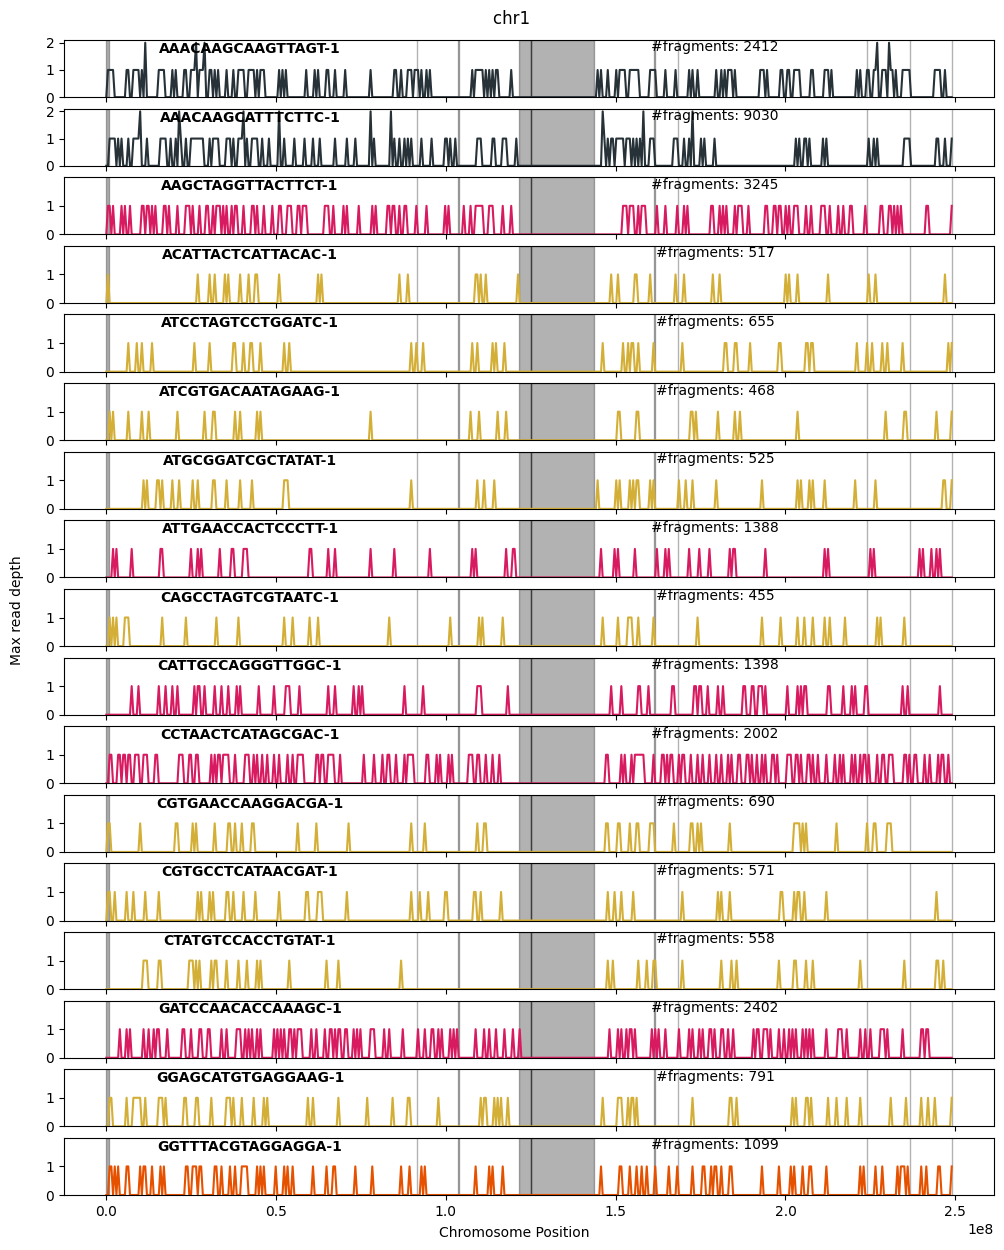

In [28]:
chrom = "chr1"
bins = 500

fig,ax = plt.subplots(ncols=1, nrows=17, figsize=(12, 15), sharex=True)
ax = ax.flatten()

shown_methods = []
for i, bc in enumerate(bc_common_list[:2] + bc_invalid_entropy_list):
    if i >= len(ax)  :
        # ax[i].axis('off')
        # handles=[mpatches.Patch(color=cat_colors_map[method], label=method) for method in unique_categories if method in set(shown_methods)]
        # ax[i].legend(handles=handles, loc='upper right', bbox_to_anchor=(0.8, 1), title='Identified by')
        break
    identified_method = union_cell_info.loc[bc, '_3set_identified_by_atac']
    shown_methods.append(identified_method)
    read_depth = total_frag_per_bc.loc[bc]
        
    bc_bw_file = os.path.join(per_bc_subdir, f'{bc}-1_fragments.bw')
    bc_bw = pyBigWig.open(bc_bw_file)
    bc_chrom_size = bc_bw.chroms(chrom)
    bc_binned_stats = bc_bw.stats(chrom, 0, bc_chrom_size, nBins=bins, type="max")

    ax[i].plot(np.linspace(0, bc_chrom_size, bins), bc_binned_stats, label=bc, color=cat_colors_map.get(identified_method, 'grey'))
    ax[i].text(0.7, 0.8, f'#fragments: {read_depth}', transform=ax[i].transAxes, ha='center', fontsize=10, color='black')
    ax[i].set_title(f'{bc}-1', fontsize=10,   pad=1, x=0.2, y=0.75, fontweight='bold')
    y_lim = max(ax[i].get_ylim()[1], 2)
    ax[i].set_ylim(0, y_lim)
    ax[i].set_yticks(np.arange(y_lim))
    
    # annotate blacklist regions
    chrom_blacklist = blacklist_region_df[blacklist_region_df['chrom'] == chrom]
    for _, row in chrom_blacklist.iterrows():
        ax[i].axvspan(row['start'], row['end'], color='black', alpha=0.3)
    bc_bw.close()



fig.suptitle(f'{chrom} ', y=0.9)
fig.supylabel('Max read depth',fontsize=10,  x=0.08, y=0.5, )
fig.supxlabel("Chromosome Position",fontsize=10,  x=0.5, y=0.08, )


## DNA-debris 

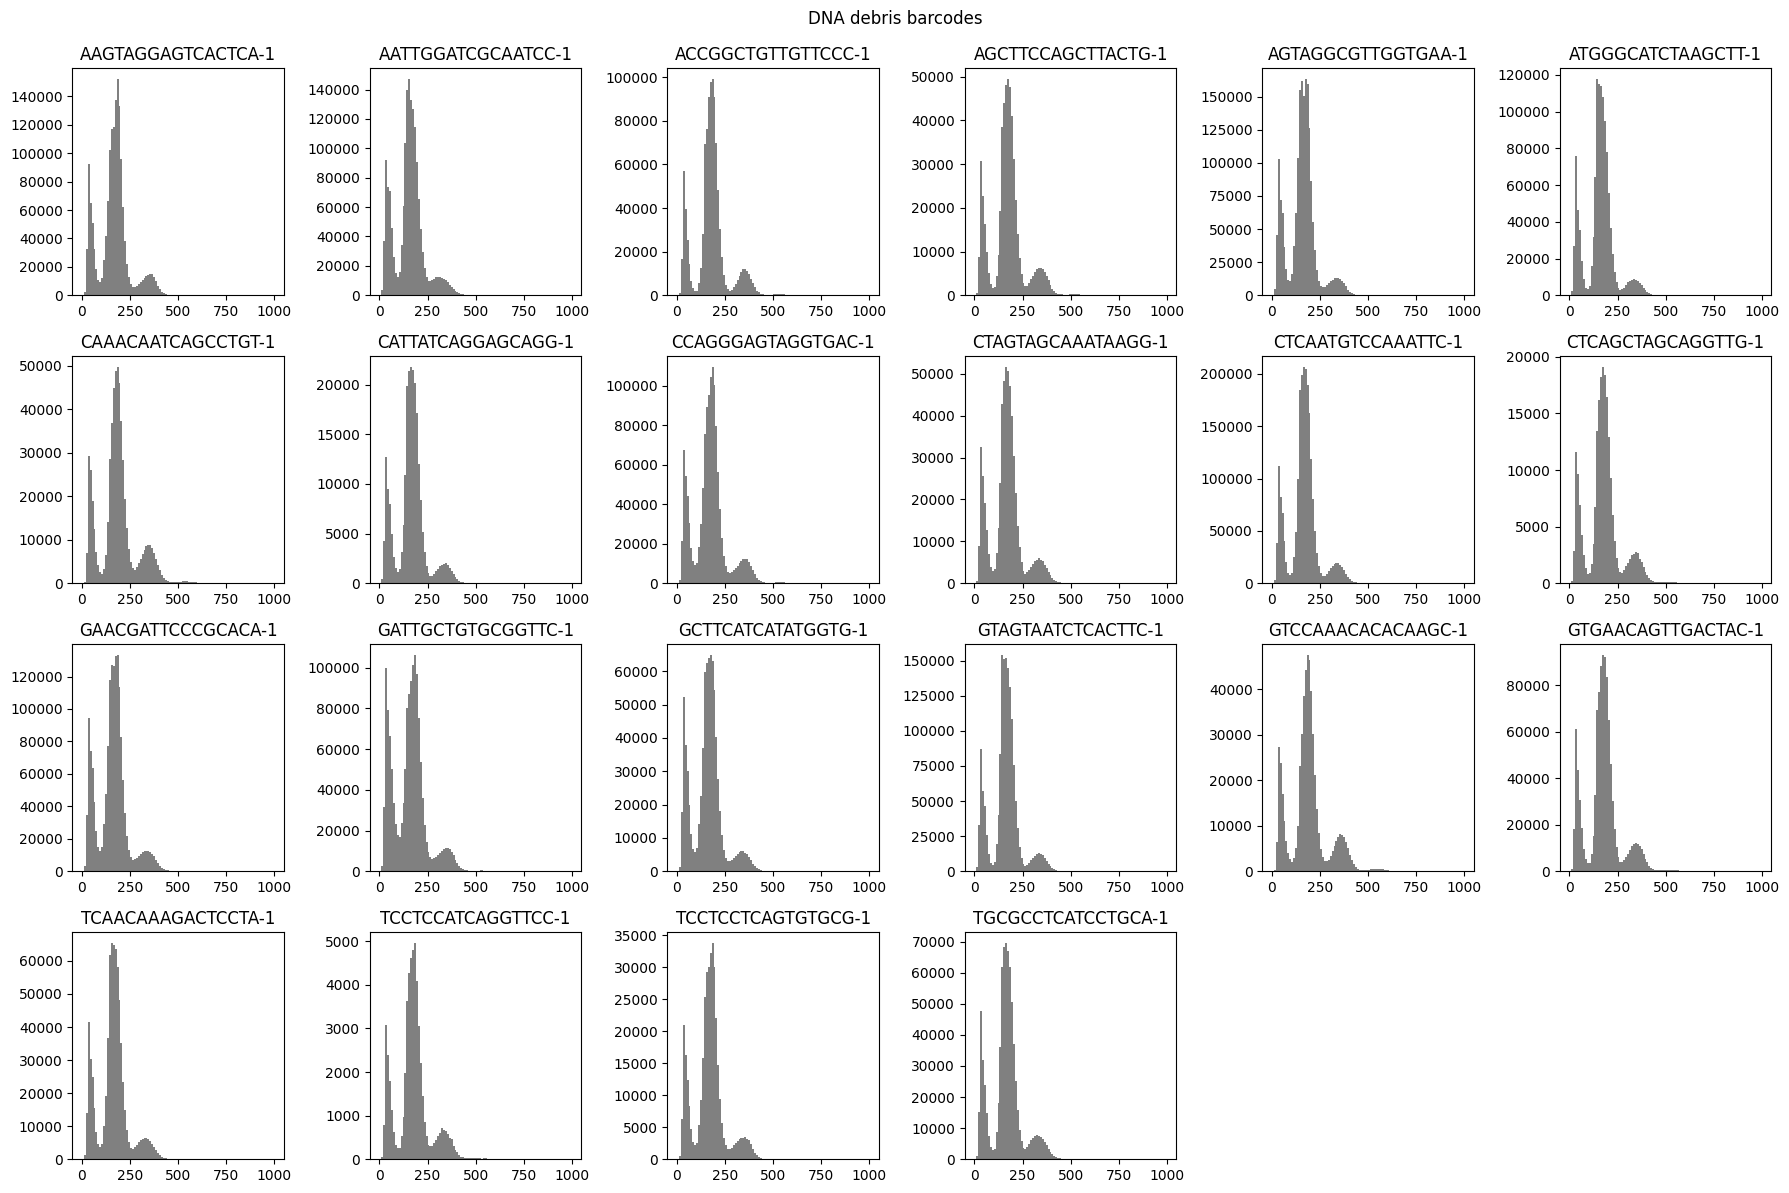

In [29]:
total_sub_fig = len(bc_DNAdebris_list)
ncol = 6
nrow = 4
fig, ax = plt.subplots(nrow, ncol, figsize=(ncol*3, nrow*3))
ax = ax.flatten()

for i, bc in enumerate(bc_DNAdebris_list):
    if i >= nrow*ncol:
        break
    _ = ax[i].hist(frag.loc[frag['atac_bc'] == bc, 'frag_length'], bins=100, range=(0, 1000), color='grey')
    ax[i].set_title(bc + '-1')
for j in range(i+1, nrow*ncol):
    ax[j].axis('off')

fig.suptitle('DNA debris barcodes', y=0.99, fontsize=12)
fig.tight_layout()

# See method unique barcode's fragment length distribution

In [30]:
frag_tss = frag.loc[frag['atac_bc'].isin(bc_tss_only_list), 'frag_length']
frag_tss.shape

(249811,)

In [31]:
frag_entropy = frag.loc[frag['atac_bc'].isin(bc_entropy_only_list), 'frag_length']
frag_entropy.shape

(128843,)

In [32]:
frag_cr = frag.loc[frag['atac_bc'].isin(bc_cr_only_list), 'frag_length']
frag_cr.shape

(22226860,)

In [33]:
frag_common = frag.loc[frag['atac_bc'].isin(bc_common_list), 'frag_length']
frag_common.shape

(18205206,)

In [34]:
frag_TSS_CR = frag.loc[frag['atac_bc'].isin(bc_CRnTSS_list), 'frag_length']
frag_TSS_CR.shape

(68217,)

In [35]:
frag_SADE_CR = frag.loc[frag['atac_bc'].isin(bc_SADEnCR_list), 'frag_length']
frag_SADE_CR.shape

(2788597,)

In [36]:
frag_SADE_TSS = frag.loc[frag['atac_bc'].isin(bc_SADEnTSS_list), 'frag_length']
frag_SADE_TSS.shape

(323640,)

In [37]:
for n, s in zip(['common', 'SADE unique', 'CR unique', 'TSS unique', 'CR+TSS, not SADE', 'SADE+CR, not TSS', 'SADE+TSS, not CR'], 
          [frag_common, frag_entropy, frag_cr, frag_tss, frag_TSS_CR, frag_SADE_CR, frag_SADE_TSS]):
    s.name = n

total_bc_counts = {}
for n, l in zip(['common', 'SADE unique', 'CR unique', 'TSS unique', 'CR+TSS, not SADE', 'SADE+CR, not TSS', 'SADE+TSS, not CR'], 
      [bc_common_list, bc_entropy_only_list, bc_cr_only_list, bc_tss_only_list, bc_CRnTSS_list, bc_SADEnCR_list, bc_SADEnTSS_list]):
      total_bc_counts[n] = len(l)

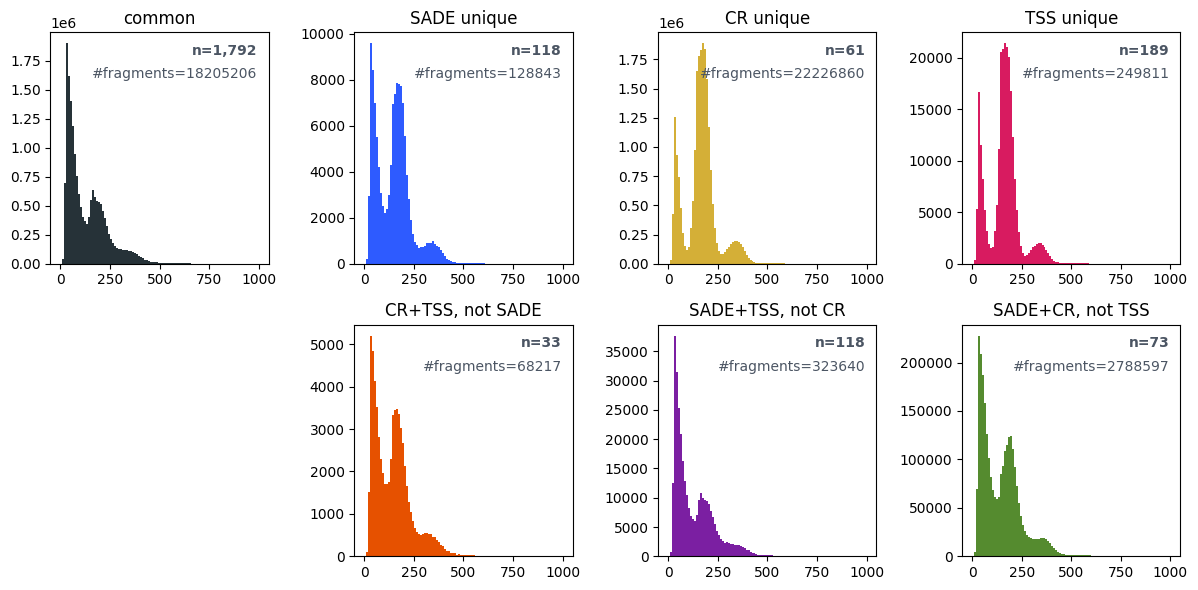

In [38]:
fig, ax = plt.subplots(ncols=4, nrows=2, figsize=(12,6))
ax = ax.flatten()
for s, i  in zip([frag_common, frag_entropy, frag_cr, frag_tss, None,  frag_TSS_CR, frag_SADE_TSS, frag_SADE_CR], range(8)):
    if s is None:
        ax[i].axis('off')
        continue
    _ = ax[i].hist(s, bins=100, range=(0, 1000), color=cat_colors_map.get(s.name, 'grey'))
    ax[i].set_title(s.name)
    ax[i].text(0.95, 0.95, f'n={total_bc_counts.get(s.name, 0):,}', transform=ax[i].transAxes, ha='right', va='top', fontsize=10, color='#4B5563', fontweight='bold')
    ax[i].text(0.95, 0.85, f'#fragments={len(s)}', transform=ax[i].transAxes, ha='right', va='top', fontsize=10, color='#4B5563')

fig.tight_layout()

In [69]:
set_identified_bw_subdir = os.path.join(Union_cell_subdir, 'cmp_3Set')

set_bw_files = {}
for n in ['common', 'SADE unique', 'CR unique', 'TSS unique', 'CR+TSS, not SADE', 'SADE+CR, not TSS', 'SADE+TSS, not CR']:
    file_name = f'sorted_farg_{n.replace(" ", "_", -1).replace(",", "_")}.bw'
    set_bw_files[n] = os.path.join(set_identified_bw_subdir, file_name)
    

### Regions  
IL7R  chr5:35,854,891-35,881,603  
LEF1 chr4:108,045,548-108,170,932  
LYZ chr12:69,346,381-69,356,234  
GNB1  chr1:1,783,286-1,893,087

/tmp/ipykernel_1982947/4112704396.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].set_title(f'reads in barcodes set {s}', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', color=cat_colors_map.get(s, 'grey')), pad=2)


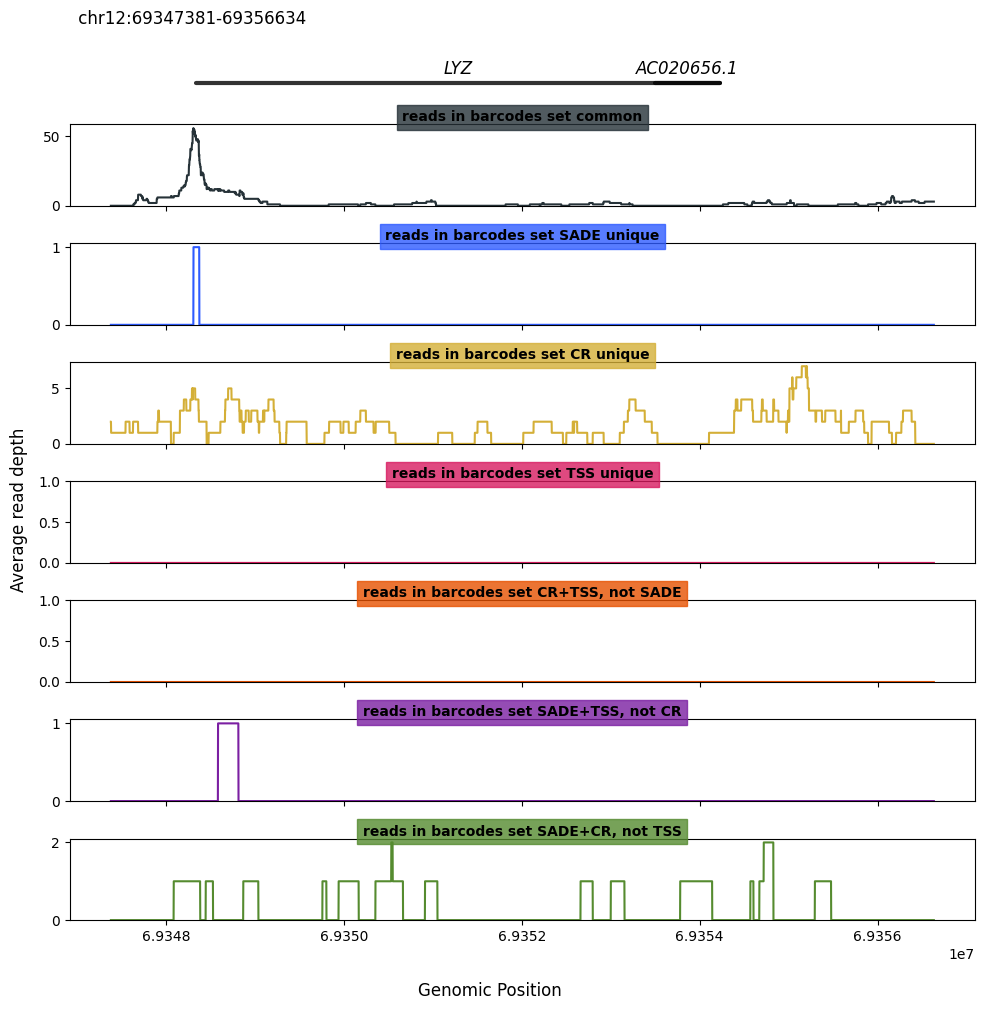

In [219]:

chrom = "chr12"
start = 69347381
end = 69356634
ratios = [0.1] + [1] * len(set_bw_files)

fig, ax = plt.subplots( nrows=8,  ncols=1, figsize=(10, 10), sharex=True, 
    gridspec_kw={'height_ratios': ratios}
)
ax = ax.flatten()

for j, s in enumerate(unique_categories):
    i = j + 1
    bw_file = set_bw_files[s]
    bw = pyBigWig.open(bw_file)
    values = bw.values(chrom, start, end)
    values = np.nan_to_num(values, nan=0.0)
    ax[i].plot(range(start, end), values, label=s, color=cat_colors_map.get(s, 'grey'))
    ax[i].set_title(f'reads in barcodes set {s}', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', color=cat_colors_map.get(s, 'grey')), pad=2)
    y_lim = max(ax[i].get_ylim()[1], 1)
    ax[i].set_ylim(0, y_lim)
    
    bw.close()

# Annotate genes in the region
genes_in_region = (hg38_genes_genes_df['chrom'] == chrom) & (hg38_genes_genes_df['start'] >= start) & (hg38_genes_genes_df['end'] <= end)
genes = hg38_genes_genes_df[genes_in_region][['gene_name', 'start', 'end']]
for gene in genes.itertuples():
    ax[0].axis('off')
    # Draw the main gene line and annotate the gene name
    ax[0].plot([gene.start, gene.end], [1, 1],  lw=3,color='black',solid_capstyle='round', alpha=0.8)
    ax[0].text((gene.start + gene.end)/2, 1.3, gene.gene_name, 
                ha='center', va='top', fontsize=12, fontstyle='italic')

# handles = [mpatches.Patch(color=cat_colors_map[s], label=s) for s in set_bw_files.keys()]
# fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(1, 0.9), title='Identified by', fontsize=10)

fig.suptitle(f" {chrom}:{start}-{end}", x=0.2, y=1, fontsize=12,)
fig.supxlabel("Genomic Position", fontsize=12)
fig.supylabel("Average read depth", fontsize=12)
fig.tight_layout()

/tmp/ipykernel_1982947/2495798404.py:20: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].set_title(f'reads in barcodes set {s}', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', color=cat_colors_map.get(s, 'grey')), pad=2)


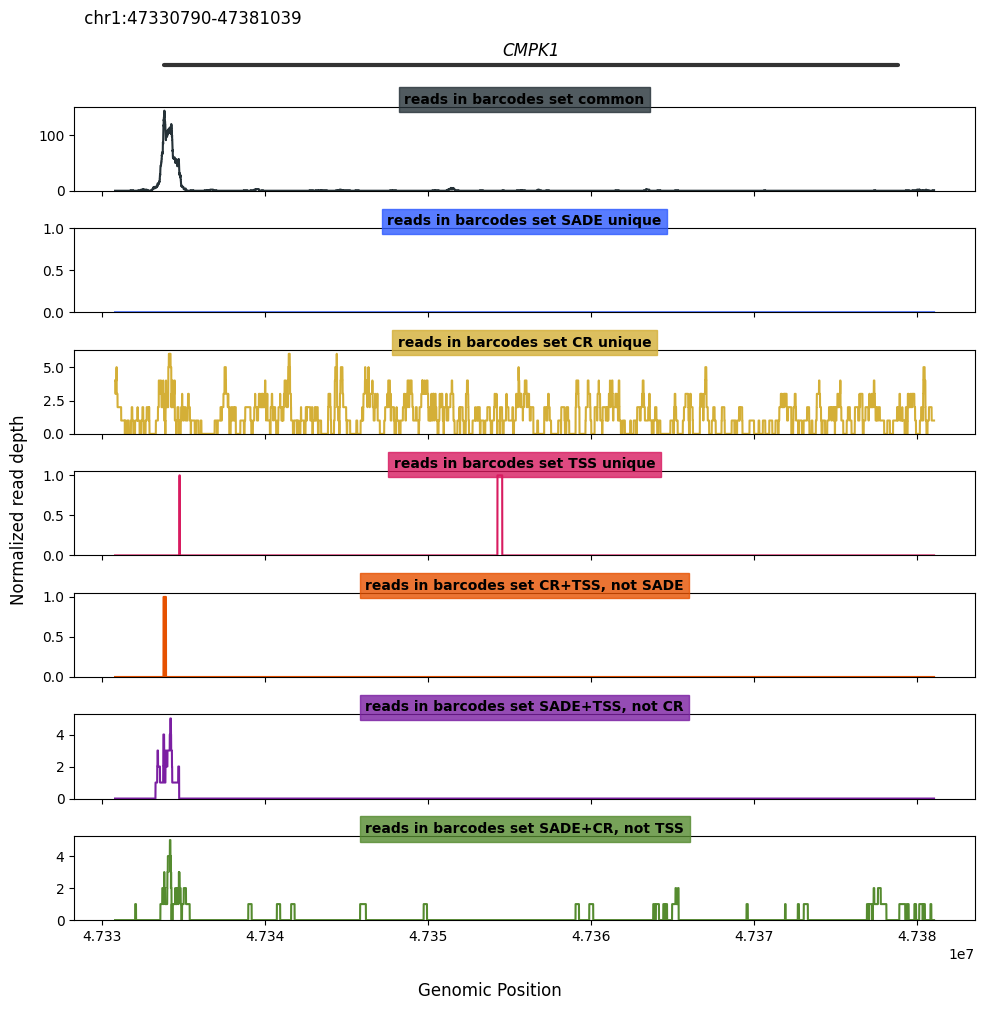

In [214]:
chrom = "chr1"
start = 47330790
end = 47381039


ratios = [0.1] + [1] * len(set_bw_files)

fig, ax = plt.subplots( nrows=8,  ncols=1, figsize=(10, 10), sharex=True, 
    gridspec_kw={'height_ratios': ratios}
)
ax = ax.flatten()

for j, s in enumerate(unique_categories):
    i = j + 1
    bw_file = set_bw_files[s]
    bw = pyBigWig.open(bw_file)
    values = bw.values(chrom, start, end)
    values = np.nan_to_num(values, nan=0.0)
    ax[i].plot(range(start, end), values, label=s, color=cat_colors_map.get(s, 'grey'))
    ax[i].set_title(f'reads in barcodes set {s}', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', color=cat_colors_map.get(s, 'grey')), pad=2)
    y_lim = max(ax[i].get_ylim()[1], 1)
    ax[i].set_ylim(0, y_lim)
    
    bw.close()

# Annotate genes in the region
genes_in_region = (hg38_genes_genes_df['chrom'] == chrom) & (hg38_genes_genes_df['start'] >= start) & (hg38_genes_genes_df['end'] <= end)
genes = hg38_genes_genes_df[genes_in_region][['gene_name', 'start', 'end']]
for gene in genes.itertuples():
    ax[0].axis('off')
    # Draw the main gene line and annotate the gene name
    ax[0].plot([gene.start, gene.end], [1, 1],  lw=3,color='black',solid_capstyle='round', alpha=0.8)
    ax[0].text((gene.start + gene.end)/2, 1.3, gene.gene_name, 
                ha='center', va='top', fontsize=12, fontstyle='italic')

fig.suptitle(f" {chrom}:{start}-{end}", x=0.2, y=1, fontsize=12,)
fig.supxlabel("Genomic Position", fontsize=12)
fig.supylabel("Normalized read depth", fontsize=12)
fig.tight_layout()

/tmp/ipykernel_1982947/3340851377.py:20: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].set_title(f'reads in barcodes set {s}', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', color=cat_colors_map.get(s, 'grey')), pad=2)


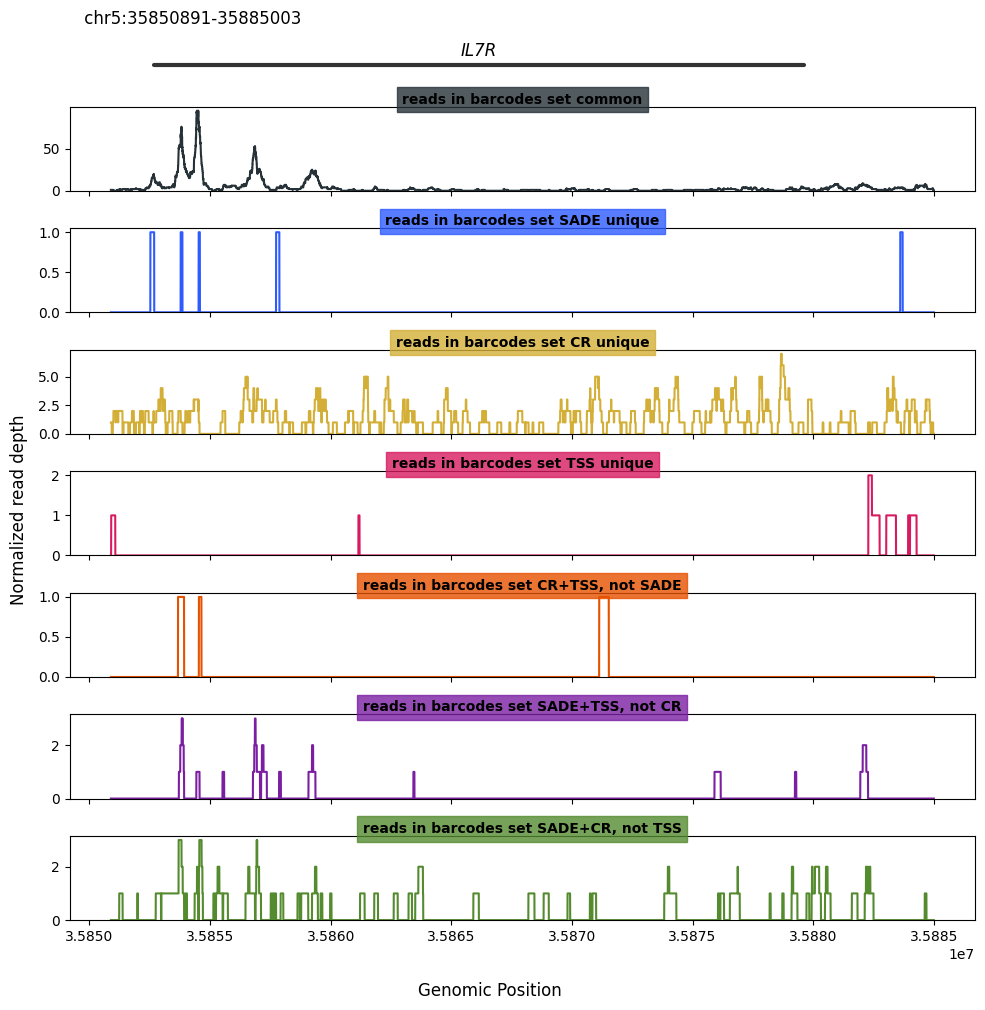

In [215]:
chrom = "chr5"
start = 35850891
end = 35885003


ratios = [0.1] + [1] * len(set_bw_files)

fig, ax = plt.subplots( nrows=8,  ncols=1, figsize=(10, 10), sharex=True, 
    gridspec_kw={'height_ratios': ratios}
)
ax = ax.flatten()

for j, s in enumerate(unique_categories):
    i = j + 1
    bw_file = set_bw_files[s]
    bw = pyBigWig.open(bw_file)
    values = bw.values(chrom, start, end)
    values = np.nan_to_num(values, nan=0.0)
    ax[i].plot(range(start, end), values, label=s, color=cat_colors_map.get(s, 'grey'))
    ax[i].set_title(f'reads in barcodes set {s}', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', color=cat_colors_map.get(s, 'grey')), pad=2)
    y_lim = max(ax[i].get_ylim()[1], 1)
    ax[i].set_ylim(0, y_lim)
    
    bw.close()

# Annotate genes in the region
genes_in_region = (hg38_genes_genes_df['chrom'] == chrom) & (hg38_genes_genes_df['start'] >= start) & (hg38_genes_genes_df['end'] <= end)
genes = hg38_genes_genes_df[genes_in_region][['gene_name', 'start', 'end']]
for gene in genes.itertuples():
    ax[0].axis('off')
    # Draw the main gene line and annotate the gene name
    ax[0].plot([gene.start, gene.end], [1, 1],  lw=3,color='black',solid_capstyle='round', alpha=0.8)
    ax[0].text((gene.start + gene.end)/2, 1.3, gene.gene_name, 
                ha='center', va='top', fontsize=12, fontstyle='italic')

fig.suptitle(f" {chrom}:{start}-{end}", x=0.2, y=1, fontsize=12,)
fig.supxlabel("Genomic Position", fontsize=12)
fig.supylabel("Normalized read depth", fontsize=12)
fig.tight_layout()

Text(0.5, 0.08, 'Chromosome Position')

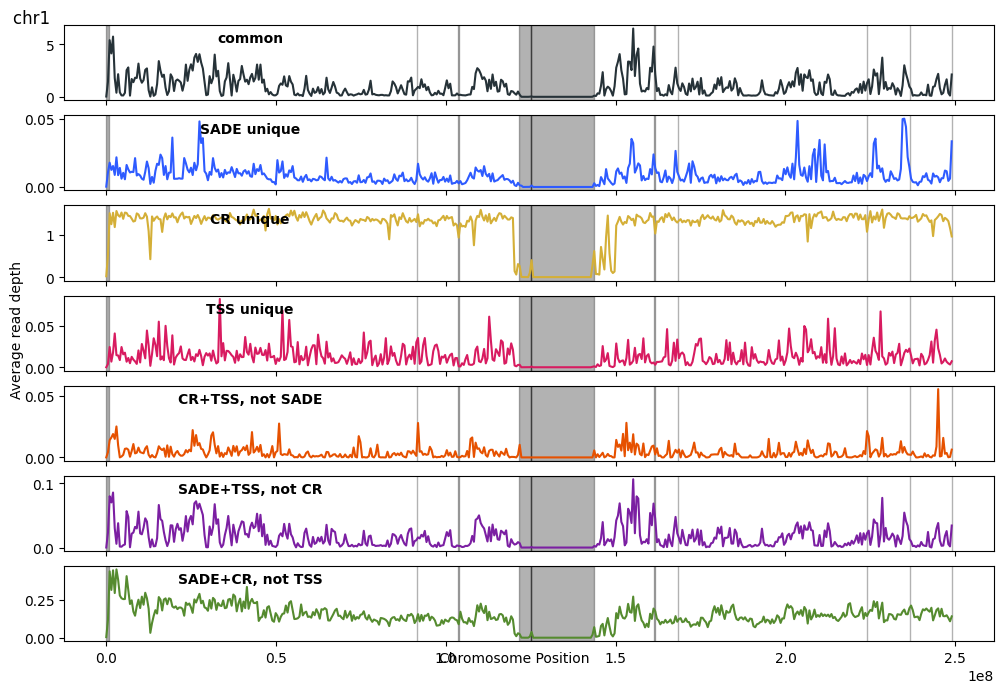

In [218]:
chrom = "chr1"
bins = 500

fig,ax = plt.subplots(ncols=1, nrows=7, figsize=(12, 8), sharex=True, sharey=False)
ax = ax.flatten()


for i, s in enumerate(unique_categories):

    bw_file = set_bw_files[s]
    bw = pyBigWig.open(bw_file)
    bw_chrom_size = bw.chroms(chrom)
    bw_binned_stats = bw.stats(chrom, 0, bw_chrom_size, nBins=bins, type="mean")


    ax[i].plot(np.linspace(0, bw_chrom_size, bins), bw_binned_stats, label=s, color=cat_colors_map.get(s, 'grey'))
    ax[i].set_title(f'{s}', fontsize=10,   pad=1, x=0.2, y=0.75, fontweight='bold')
    
    # annotate blacklist regions
    chrom_blacklist = blacklist_region_df[blacklist_region_df['chrom'] == chrom]
    for _, row in chrom_blacklist.iterrows():
        ax[i].axvspan(row['start'], row['end'], color='black', alpha=0.3)
    bc_bw.close()



fig.suptitle(f'{chrom} ', y=0.9, x=0.1)
fig.supylabel('Average read depth',fontsize=10,  x=0.08, y=0.5, )
fig.supxlabel("Chromosome Position",fontsize=10,  x=0.5, y=0.08, )


# Each filtering nuclei set 

In [ ]:
# sade_nuclei_bc_list = union_cell_info.loc[union_cell_info['atac_pass_entropy'] == True].index.tolist()
# tsse_nuclei_bc_list = union_cell_info.loc[union_cell_info['atac_pass_archr_TSS'] == True].index.tolist()
# cr_nuclei_bc_list = union_cell_info.loc[union_cell_info['atac_pass_CR'] == True].index.tolist()

In [125]:
frag.head(2)

,chrom,start,end,support,atac_bc,frag_length
atac_BC,,,,,,
AGTAGGCGTCCATTAA-1,chr1,10067,10198,1,AGTAGGCGTCCATTAA,131
TGAGGCATCATCAGTT-1,chr1,10085,10333,3,TGAGGCATCATCAGTT,248


Text(0.4, -0.05, 'Fragments length')

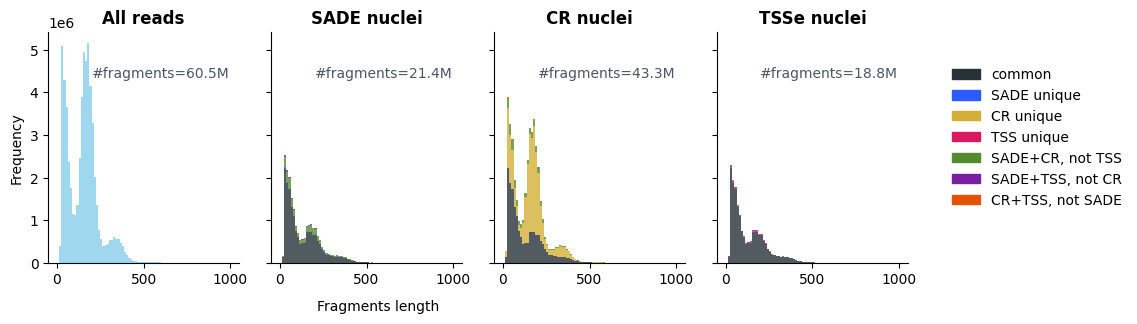

In [138]:

sade_nuclei_frag = [frag_common, frag_entropy, frag_SADE_CR, frag_SADE_TSS]
cr_nuclei_frag = [frag_common, frag_cr, frag_SADE_CR, frag_TSS_CR]
tss_nuclei_frag = [frag_common, frag_tss, frag_SADE_TSS, frag_TSS_CR]
all_reads = [frag['frag_length']]

sade_colors = [cat_colors_map.get(s, 'grey') for s in ['common', 'SADE unique', 'SADE+CR, not TSS', 'SADE+TSS, not CR']]
cr_colors = [cat_colors_map.get(s, 'grey') for s in ['common', 'CR unique', 'SADE+CR, not TSS', 'CR+TSS, not SADE']]
tss_colors = [cat_colors_map.get(s, 'grey') for s in ['common', 'TSS unique', 'SADE+TSS, not CR', 'CR+TSS, not SADE']]
all_reads_colors = ['green']

fig, ax = plt.subplots(ncols=5, nrows=1, figsize=(12,3),gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.2]}, sharey=True)
ax = ax.flatten()

# All reads 
ax[0].hist(all_reads, bins=80, range=(0, 1000), color='skyblue', alpha=0.8, edgecolor='none')
ax[0].text(0.95, 0.85, f'#fragments={len(frag) / 1e6:.1f}M', transform=ax[0].transAxes, ha='right', va='top', fontsize=10, color='#4B5563')
ax[0].set_title('All reads', fontweight='bold')
ax[0].spines[['top', 'right']].set_visible(False)

for s, c, t, i in zip([sade_nuclei_frag, cr_nuclei_frag, tss_nuclei_frag], 
                   [sade_colors, cr_colors, tss_colors],
                   ['SADE', 'CR', 'TSSe'], 
                   range(1, 4)):
    _ = ax[i].hist(s, bins=80, range=(0, 1000), stacked=True, color=c, alpha=0.8, edgecolor='none')
    ax[i].set_title(f"{t} nuclei", fontweight='bold')
    # ax[i].text(0.95, 0.95, f'n={total_bc_counts.get(s.name, 0):,}', transform=ax[i].transAxes, 
    #            ha='right', va='top', fontsize=10, color='#4B5563', fontweight='bold')
    ax[i].text(0.95, 0.85, f'#fragments={np.sum([len(frag) for frag in s]) / 1e6:.1f}M', 
               transform=ax[i].transAxes, ha='right', va='top', fontsize=10, color='#4B5563')
    ax[i].spines[['top', 'right']].set_visible(False)



ax[4].axis('off')
handles = [mpatches.Patch(color=cat_colors_map[s], label=s) for s in unique_categories] 
ax[4].legend(handles=handles, frameon=False, loc='upper left', bbox_to_anchor=(0, 0.9), title='', fontsize=10)

ax[0].set_ylabel('Frequency')
fig.text(0.4, -0.05, 'Fragments length', ha='center')#, fontweight='bold')


In [75]:
eachset_identified_bw_subdir = os.path.join(Union_cell_subdir, 'cmp_3Set', 'filtering_method_set')

eachset_bw_files = {}
for n in ['atac_pass_entropy', 'atac_pass_CR', 'atac_pass_archr_TSS',]:
    file_name = f'sorted_farg_{n}.bw'
    eachset_bw_files[n] = os.path.join(eachset_identified_bw_subdir, file_name)


In [243]:
chrom = "chr5"
start = 35850891
end = 35885003

#IL7R

Text(0.3, 0.01, 'Genomic position on chr12 (bp)')

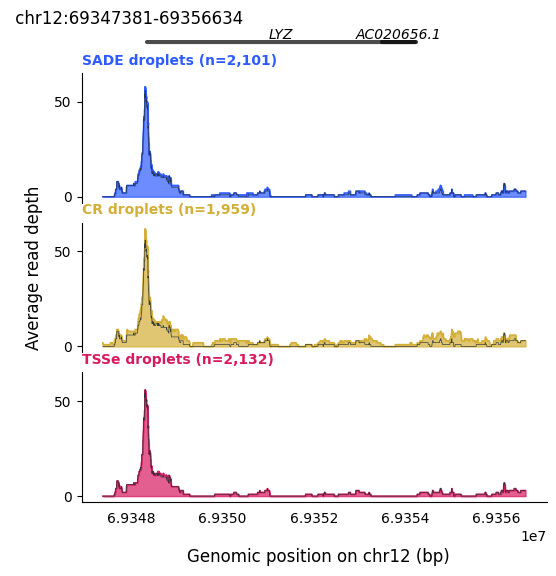

In [235]:
chrom = "chr12"
start = 69347381
end = 69356634

ratios = [0.1] + [1] * len(eachset_bw_files) 

fig, ax = plt.subplots( nrows=4,  ncols=1, figsize=(6, 6), sharex=True, sharey=True,
    gridspec_kw={'height_ratios': ratios}
)
ax = ax.flatten()

set_colors = [ '#2E5BFF', "#D4AF37", '#D81B60']
labels = ['SADE droplets', 'CR droplets', 'TSSe droplets']
for j, s in enumerate(['atac_pass_entropy', 'atac_pass_CR', 'atac_pass_archr_TSS']):
    i = j + 1
    x_range = np.arange(start, end)
     
    bw_file = eachset_bw_files[s]
    bw = pyBigWig.open(bw_file)
    values = bw.values(chrom, start, end)
        
    # Process Common Reference BigWig
    c_bw = pyBigWig.open(set_bw_files['common'])
    common_values = np.nan_to_num(c_bw.values(chrom, start, end), nan=0.0)
    
    ax[i].fill_between(x_range, values, color=set_colors[j], alpha=0.7, label=labels[j])
    ax[i].plot(x_range, values, color=set_colors[j], lw=1)
    # Common
    # ax[i].fill_between(x_range, common_values, color='#263238', alpha=0.15, label='Common')
    ax[i].plot(x_range, common_values, color='#263238', lw=0.5, alpha=0.9)
    
    ax[i].set_title(f'{labels[j]} (n={union_cell_info[s].sum():,})', 
                    loc='left', fontsize=10, fontweight='bold', color=set_colors[j])
    ax[i].spines[['top', 'right', 'bottom']].set_visible(False)
    ax[i].tick_params(axis='x', which='both', bottom=False)
    
    bw.close()
    c_bw.close()

# Annotate genes in the region
genes_in_region = (hg38_genes_genes_df['chrom'] == chrom) & (hg38_genes_genes_df['start'] >= start) & (hg38_genes_genes_df['end'] <= end)
genes = hg38_genes_genes_df[genes_in_region][['gene_name', 'start', 'end']]
for gene in genes.itertuples():
    ax[0].axis('off')
    # Draw the main gene line and annotate the gene name
    ax[0].plot([gene.start, gene.end], [0.8 *ax[-1].get_ylim()[1]] * 2,  lw=3,color='black',solid_capstyle='round', alpha=0.7)
    ax[0].text((gene.start + gene.end)/2, ax[-1].get_ylim()[1] *2, gene.gene_name, 
                ha='center', va='top', fontsize=10, fontstyle='italic')

ax[-1].spines['bottom'].set_visible(True)

fig.suptitle(f" {chrom}:{start}-{end}", x=0.2, y=0.93, fontsize=12,)
fig.text(0.03, 0.5, "Average read depth", fontsize=12, rotation=90, va='center')
fig.text(0.3, 0.01, f"Genomic position on {chrom} (bp)", fontsize=12)

#fig.tight_layout()

In [236]:
chrom = "chr1"
start = 47330790
end = 47381039


Text(0.5, 0.02, 'Chromosome Position on chr1 (bp)')

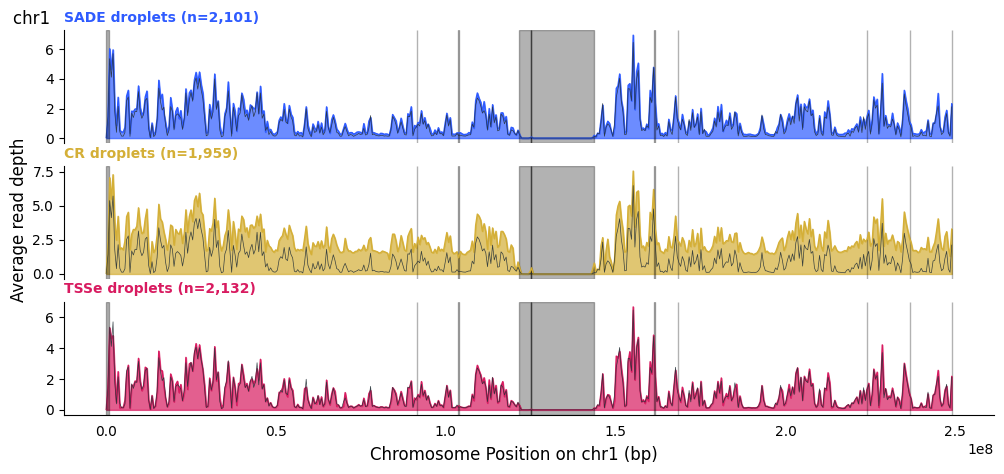

In [241]:
chrom = "chr1"
bins = 500

fig,ax = plt.subplots(ncols=1, nrows=3, figsize=(12, 5), sharex=True)
ax = ax.flatten()

set_colors = [ '#2E5BFF', "#D4AF37", '#D81B60']
labels = ['SADE droplets', 'CR droplets', 'TSSe droplets']
for j, s in enumerate(['atac_pass_entropy', 'atac_pass_CR', 'atac_pass_archr_TSS']):
    i = j 
    
    bw_file = eachset_bw_files[s]
    bw = pyBigWig.open(bw_file)
    bw_chrom_size = bw.chroms(chrom)
    bw_binned_stats = bw.stats(chrom, 0, bw_chrom_size, nBins=bins, type="mean")

    ref_bw_file = set_bw_files['common']
    ref_bw = pyBigWig.open(ref_bw_file)
    ref_bw_chrom_size = ref_bw.chroms(chrom)
    ref_bw_binned_stats = ref_bw.stats(chrom, 0, ref_bw_chrom_size, nBins=bins, type="mean")
    
    x_range = np.linspace(0, bw_chrom_size, bins)
    
    ax[i].fill_between(x_range, bw_binned_stats, color=set_colors[j], alpha=0.7, label=labels[j])
    ax[i].plot(x_range, bw_binned_stats, color=set_colors[j], lw=1)
    # Common
    ax[i].plot(x_range, ref_bw_binned_stats, color='#263238', lw=0.5, alpha=0.9)
    
    ax[i].set_title(f'{labels[j]} (n={union_cell_info[s].sum():,})', 
                    loc='left', fontsize=10, fontweight='bold', color=set_colors[j])
    ax[i].spines[['top', 'right', 'bottom']].set_visible(False)
    ax[i].tick_params(axis='x', which='both', bottom=False)
    
    bc_bw.close()
    ref_bw.close()
    
    # annotate blacklist regions
    chrom_blacklist = blacklist_region_df[blacklist_region_df['chrom'] == chrom]
    for _, row in chrom_blacklist.iterrows():
        ax[i].axvspan(row['start'], row['end'], color='black', alpha=0.3)

ax[-1].spines['bottom'].set_visible(True)

fig.suptitle(f'{chrom} ', y=0.92, x=0.1,fontsize=12)
fig.text(0.08, 0.5, 'Average read depth', fontsize=12, rotation=90, va='center')
fig.text(0.5, 0.02, f"Chromosome Position on {chrom} (bp)",fontsize=12,  rotation=0, ha='center')